In [ ]:
Names: TUYISHIME EVODE   26057497
Names: KAMUHANDA Safari  2405001207

## 1. Load Data

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('Temperature Dataset.csv')
print(df.shape)
df.head()


(9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## 2. Features & Target

In [2]:
X = df.iloc[:, :-1].values   
y = df.iloc[:, -1].values    


## 3. Train/Test Split

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (7654, 4)  Test: (1914, 4)


## 4. Results Tracker
A simple dictionary to store each model's R² score so we can compare them at the end.

In [4]:
from sklearn.metrics import r2_score

results = {}  


---
## Model 1 — Linear Regression

In [5]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)
results['Linear Regression'] = r2_score(y_test, y_pred)
print("R2 Score:", results['Linear Regression'])


R2 Score: 0.9325315554761302


---
## Model 2 — Polynomial Regression


In [6]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

y_pred = poly_reg.predict(X_test_poly)
results['Polynomial Regression'] = r2_score(y_test, y_pred)
print("R2 Score:", results['Polynomial Regression'])


R2 Score: 0.9455261541689578


---
## Model 3 — Support Vector Regression (SVR)


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

sc_X = StandardScaler()
sc_y = StandardScaler()

X_train_sc = sc_X.fit_transform(X_train)
y_train_sc = sc_y.fit_transform(y_train.reshape(-1, 1)).ravel()

svr_reg = SVR(kernel='rbf')
svr_reg.fit(X_train_sc, y_train_sc)

y_pred_sc = svr_reg.predict(sc_X.transform(X_test))
y_pred = sc_y.inverse_transform(y_pred_sc.reshape(-1, 1)).ravel()

results['SVR'] = r2_score(y_test, y_pred)
print("R2 Score:", results['SVR'])


R2 Score: 0.948078404998626


---
## Model 4 — Decision Tree Regression


In [8]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=0)
tree_reg.fit(X_train, y_train)

y_pred = tree_reg.predict(X_test)
results['Decision Tree'] = r2_score(y_test, y_pred)
print("R2 Score:", results['Decision Tree'])


R2 Score: 0.922905874177941


---
## Model 5 — Random Forest Regression


In [9]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=10, random_state=0)
rf_reg.fit(X_train, y_train)

y_pred = rf_reg.predict(X_test)
results['Random Forest'] = r2_score(y_test, y_pred)
print("R2 Score:", results['Random Forest'])


R2 Score: 0.9615908334363876


---
## Model 6 — K-Nearest Neighbors Regression


In [10]:
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train, y_train)

y_pred = knn_reg.predict(X_test)
results['KNN'] = r2_score(y_test, y_pred)
print("R2 Score:", results['KNN'])


R2 Score: 0.9493717544145772


---
## Final Comparison
All 6 regression models side by side, sorted from best to worst R² score (closer to 1.0 = better).

In [11]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'R2 Score'])
results_df = results_df.sort_values('R2 Score', ascending=False).reset_index(drop=True)
results_df


,Model,R2 Score
0,Random Forest,0.961591
1,KNN,0.949372
2,SVR,0.948078
3,Polynomial Regression,0.945526
4,Linear Regression,0.932532
5,Decision Tree,0.922906


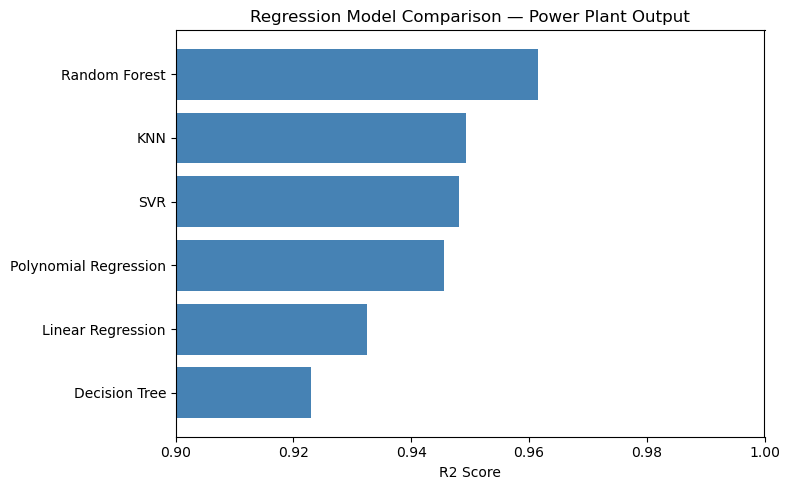

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(results_df['Model'], results_df['R2 Score'], color='steelblue')
plt.xlabel('R2 Score')
plt.title('Regression Model Comparison — Power Plant Output')
plt.xlim(0.9, 1.0)  
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
